In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
# Note: Ensure SuperStoreOrders.csv is in the same directory as your notebook
df = pd.read_csv('SuperStoreOrders.csv')

# Step 1: Display first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# Check dataset shape and info
print("\n--- Dataset Info ---")
df.info()

--- First 10 Rows ---


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011
5,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",55,2,0.1,15.342,1.80,Medium,2011
6,CA-2011-1510,2/1/2011,6/1/2011,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.0,3.120,24.10,Medium,2011
7,IN-2011-79397,3/1/2011,3/1/2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.1,110.412,125.32,Critical,2011
8,ID-2011-80230,3/1/2011,9/1/2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.464,107.10,Low,2011
9,IZ-2011-4680,3/1/2011,7/1/2011,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,...,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.320,81.26,High,2011



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          5129

In [4]:
# Convert Order Date and Ship Date into datetime format
# Standardizing separators to ensure consistency
df['order_date'] = df['order_date'].str.replace('-', '/')
df['ship_date'] = df['ship_date'].str.replace('-', '/')

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

# Convert categorical columns for memory efficiency
categorical_cols = ['category', 'region', 'segment', 'sub_category']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# FIX for Python 3.14: Use raw string (r'...') to avoid SyntaxWarnings/Errors with '\$'
# This removes dollar signs and commas from the sales string before converting to float
df['sales'] = df['sales'].replace(r'[\$,]', '', regex=True).astype(float)

print("Data Cleaning Complete. Dates and Categories updated for Python 3.14.")

Data Cleaning Complete. Dates and Categories updated for Python 3.14.


In [5]:
# Calculate basic stats
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
avg_discount = df['discount'].mean()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Discount: {avg_discount:.2%}")

# Sales and Profit Stats (Min, Max, Mean, Median)
stats = df[['sales', 'profit']].describe().loc[['min', 'max', 'mean', '50%']]
stats.rename(index={'50%': 'median'}, inplace=True)
print("\n--- Sales and Profit Statistics ---")
print(stats)

# Top 10 Products by Sales
top_10_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Products by Sales ---")
print(top_10_products)

Total Sales: $12,642,905.00
Total Profit: $1,469,034.82
Average Discount: 14.29%

--- Sales and Profit Statistics ---
              sales      profit
min         0.00000 -6599.97800
max     22638.00000  8399.97600
mean      246.49844    28.64174
median     85.00000     9.24000

--- Top 10 Products by Sales ---
product_name
Apple Smart Phone, Full Size                                86936.0
Cisco Smart Phone, Full Size                                76441.0
Motorola Smart Phone, Full Size                             73159.0
Nokia Smart Phone, Full Size                                71904.0
Canon imageCLASS 2200 Advanced Copier                       61600.0
Hon Executive Leather Armchair, Adjustable                  58200.0
Office Star Executive Leather Armchair, Adjustable          50667.0
Harbour Creations Executive Leather Armchair, Adjustable    50120.0
Samsung Smart Phone, Cordless                               48654.0
Nokia Smart Phone, with Caller ID                           478

In [6]:
# Group by Region for Sales and Profit
region_perf = df.groupby('region')[['sales', 'profit']].sum().sort_values(by='profit', ascending=False)
print("--- Regional Performance ---")
display(region_perf)

# Group by Category for Average Profit Margin
# Profit Margin = Total Profit / Total Sales
category_analysis = df.groupby('category').apply(
    lambda x: x['profit'].sum() / x['sales'].sum(), 
    include_groups=False
)
print("\n--- Category Profit Margins ---")
print(category_analysis.sort_values(ascending=False))

# Sub-Category: Identify Best and Worst
sub_cat_profit = df.groupby('sub_category')['profit'].sum().sort_values()
print(f"\nWorst Performing Sub-Category: {sub_cat_profit.idxmin()} ({sub_cat_profit.min():,.2f})")
print(f"Best Performing Sub-Category: {sub_cat_profit.idxmax()} ({sub_cat_profit.max():,.2f})")

--- Regional Performance ---


,sales,profit
region,,
Central,2822399.0,311403.98164
North,1248192.0,194597.95252
North Asia,848349.0,165578.42100
South,1600960.0,140355.76618
Central Asia,752839.0,132480.18700
Oceania,1100207.0,121666.64200
West,725514.0,108418.44890
East,678834.0,91522.78000
Africa,783776.0,88871.63100



--- Category Profit Margins ---
category
Technology         0.139899
Office Supplies    0.136897
Furniture          0.069762
dtype: float64

Worst Performing Sub-Category: Tables (-64,083.39)
Best Performing Sub-Category: Copiers (258,567.55)


In [7]:
# Group by Segment
segment_analysis = df.groupby('segment').agg({
    'sales': 'sum',
    'profit': 'sum',
    'order_id': 'count'
})
segment_analysis['avg_order_value'] = segment_analysis['sales'] / segment_analysis['order_id']

print("--- Segment Performance ---")
display(segment_analysis)

# Top 10 Customers by Sales contribution
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Customers ---")
print(top_customers)

--- Segment Performance ---


,sales,profit,order_id,avg_order_value
segment,,,,
Consumer,6508141.0,749239.78206,26518,245.423524
Corporate,3824808.0,442785.85866,15429,247.897336
Home Office,2309956.0,277009.18056,9343,247.239217



--- Top 10 Customers ---
customer_name
Tom Ashbrook          40489.0
Tamara Chand          37453.0
Greg Tran             35552.0
Christopher Conant    35187.0
Sean Miller           35170.0
Bart Watters          32315.0
Natalie Fritzler      31778.0
Fred Hopkins          30404.0
Jane Waco             30288.0
Hunter Lopez          30246.0
Name: sales, dtype: float64


In [8]:
# Resample by month (Monthly Sales Trend)
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['sales'].sum()

# Analyze shipping time (difference between Ship Date and Order Date)
df['ship_time'] = (df['ship_date'] - df['order_date']).dt.days
avg_ship_time = df['ship_time'].mean()

print(f"Average Shipping Time: {avg_ship_time:.2f} days")

Average Shipping Time: 3.97 days


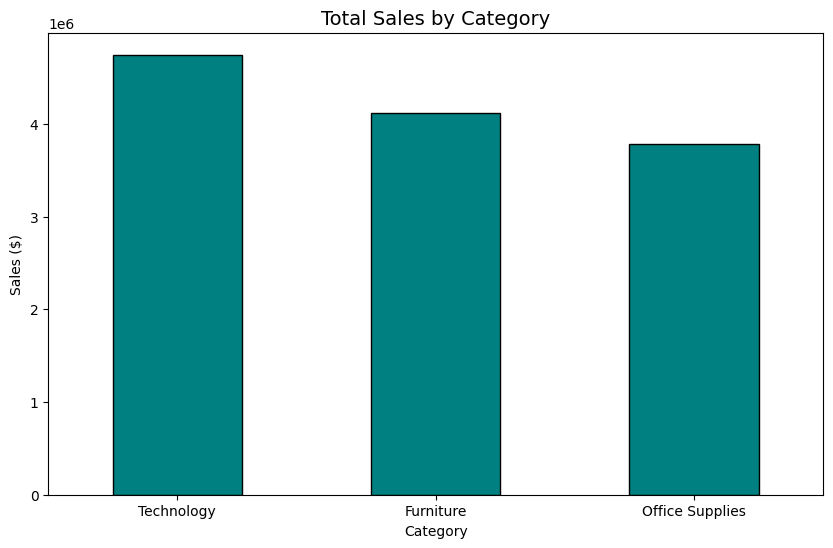

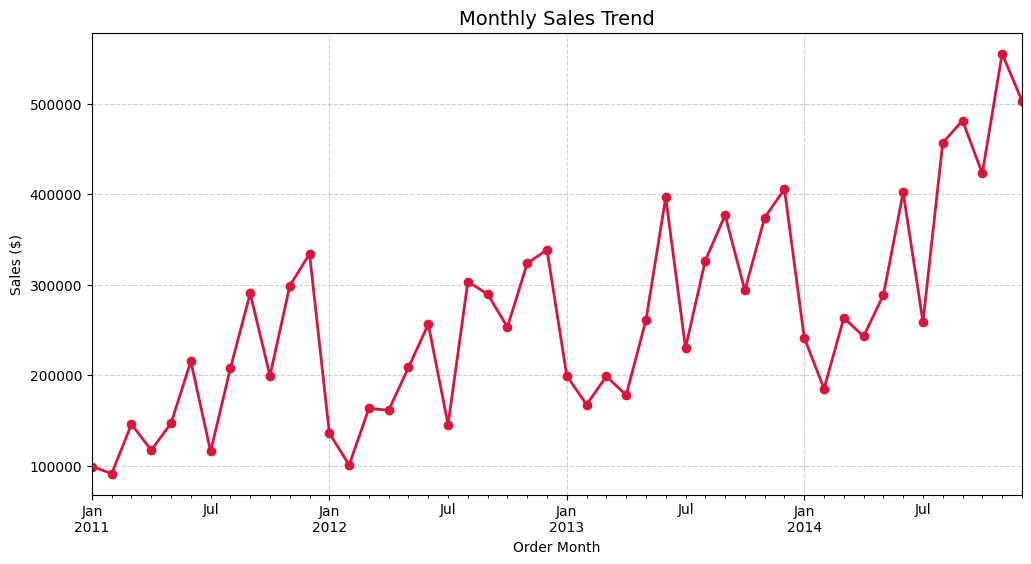

<Figure size 1400x700 with 0 Axes>

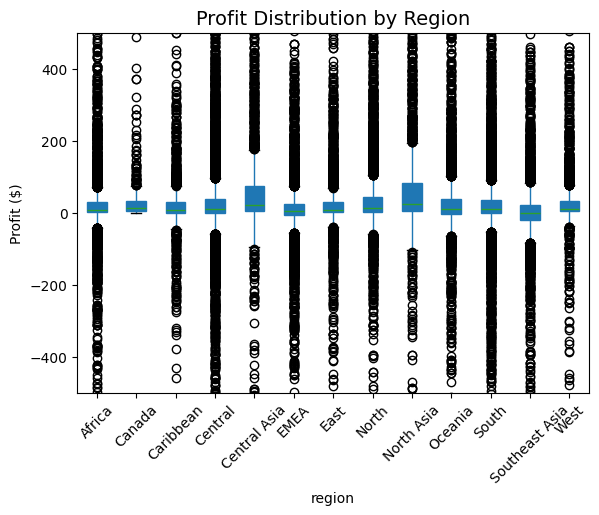

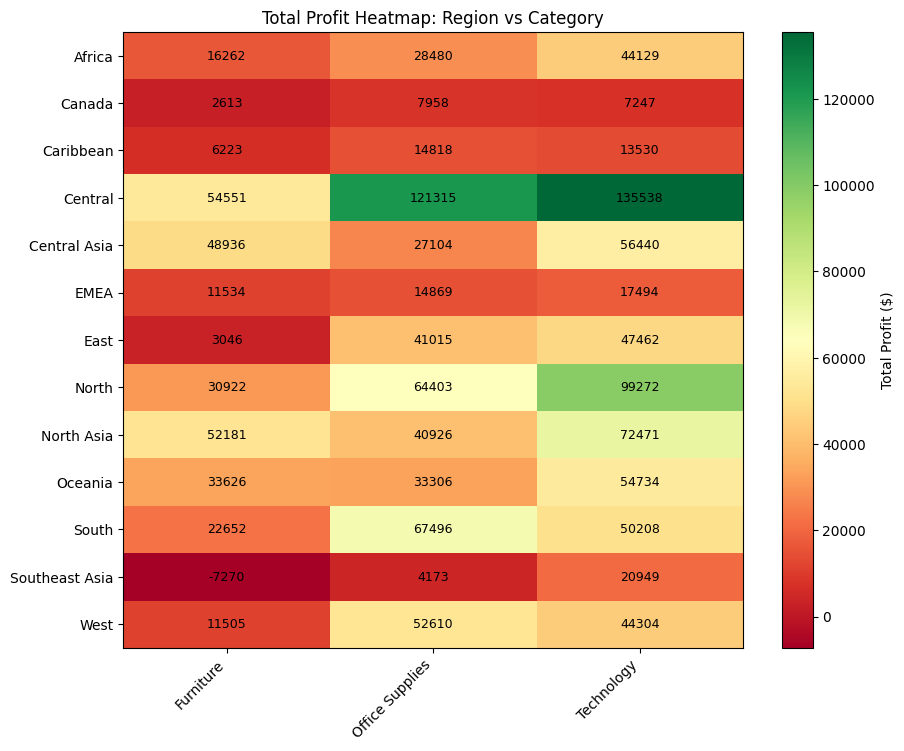

In [9]:
# 1. Bar Chart: Sales by Category
plt.figure(figsize=(10, 6))
cat_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
cat_sales.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Total Sales by Category', fontsize=14)
plt.ylabel('Sales ($)')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.show()

# 2. Line Chart: Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.ylabel('Sales ($)')
plt.xlabel('Order Month')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Boxplot: Profit Distribution by Region
plt.figure(figsize=(14, 7))
df.boxplot(column='profit', by='region', grid=False, patch_artist=True)
plt.title('Profit Distribution by Region', fontsize=14)
plt.suptitle('') # Removes default Pandas title
plt.ylabel('Profit ($)')
plt.ylim(-500, 500) # Zooming in to show the bulk of the data
plt.xticks(rotation=45)
plt.show()

# 4. Heatmap: Profit by Category vs Region
pivot_table = df.pivot_table(index='region', columns='category', values='profit', aggfunc='sum')
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot_table, cmap='RdYlGn', aspect='auto')

# Setting labels
ax.set_xticks(np.arange(len(pivot_table.columns)))
ax.set_yticks(np.arange(len(pivot_table.index)))
ax.set_xticklabels(pivot_table.columns)
ax.set_yticklabels(pivot_table.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Annotating values inside the heatmap
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        ax.text(j, i, f"{pivot_table.iloc[i, j]:.0f}", 
                ha="center", va="center", color="black", fontsize=9)

ax.set_title("Total Profit Heatmap: Region vs Category")
plt.colorbar(im, label='Total Profit ($)')
plt.show()